In [ ]:
import pandas as pd


In [ ]:
df = pd.read_csv('google-fonts.csv')

In [ ]:
df.shape

In [ ]:
df.head()

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Example DataFrame
data = np.random.rand(5, 197)
df_new = pd.DataFrame(data)

In [ ]:
for i in range(df_new.shape[0]):
    # Truncate the first 784 elements if the row is longer
    truncated_data = np.concatenate([df_new.iloc[i].values, np.zeros(784 - df_new.shape[1])])[:784]
    img_data = truncated_data.reshape(28, 28)
    plt.imshow(img_data, cmap='gray')
    plt.title(f'Image {i}')
    plt.show()

In [ ]:
from sklearn.manifold import TSNE

In [ ]:
tsne = TSNE(n_components=2, verbose=1, random_state=123)
z = tsne.fit_transform(df.iloc[:,1:])

In [ ]:
z.shape

In [ ]:
z

In [ ]:

df['x'] = z.T[0]
df['y'] = z.T[1]

In [ ]:
df.head()

In [ ]:
df.to_csv('results.csv', index=False)


In [ ]:
import plotly.express as px
fig = px.scatter(df, x="x", y="y", color="family")


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# Load the dataset
file_path = 'google-fonts.csv'
df = pd.read_csv(file_path)

# Assume the 'family' column contains the class labels
labels = df['family'].astype(str)  # Convert labels to string for easier plotting

# Drop the 'family' column since it is categorical and might be high cardinality
# Use other features for t-SNE
df_numeric = df.drop(columns=['family'])

# Convert boolean columns to numerical values
df_numeric = df_numeric.map(lambda x: 1 if x == True else 0)

# Standardize the data
scaler = StandardScaler()
X = scaler.fit_transform(df_numeric)


sample_size = 1651
X_sample = X[:sample_size]
labels_sample = labels[:sample_size]

# Apply t-SNE with reduced number of iterations
tsne = TSNE(n_components=2, random_state=42, n_iter=300, perplexity=30)
X_tsne = tsne.fit_transform(X_sample)

# Create a scatter plot with different colors for each class
plt.figure(figsize=(12, 8))
palette = sns.color_palette("hsv", len(labels_sample.unique()))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=labels_sample, palette=palette, legend='full')
plt.title('t-SNE Scatter Plot of Font Data with Different Colors for Each Class')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(loc='best', bbox_to_anchor=(1, 1), ncol=1)
plt.show()


In [18]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


C:\Users\HP\AppData\Local\Temp\ipykernel_12480\3544144366.py:20: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.





In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# Load the dataset
file_path = 'google-fonts.csv'
df = pd.read_csv(file_path)

# Assume the 'family' column contains the class labels
labels = df['family'].astype(str)  # Convert labels to string for easier plotting

# Drop the 'family' column since it is categorical and might be high cardinality
# Use other features for t-SNE
df_numeric = df.drop(columns=['family'])

# Convert boolean columns to numerical values
df_numeric = df_numeric.applymap(lambda x: 1 if x == True else 0)

# Standardize the data
scaler = StandardScaler()
X = scaler.fit_transform(df_numeric)


sample_size = 1651
X_sample = X[:sample_size]
labels_sample = labels[:sample_size]

# Apply t-SNE with reduced number of iterations
tsne = TSNE(n_components=2, random_state=42, n_iter=300, perplexity=30)
X_tsne = tsne.fit_transform(X_sample)

# Create a scatter plot with different colors for each class
plt.figure(figsize=(12, 8))
palette = sns.color_palette("hsv", len(labels_sample.unique()))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=labels_sample, palette=palette, legend='full')
plt.title('t-SNE Scatter Plot of Font Data with Different Colors for Each Class')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(loc='best', bbox_to_anchor=(1, 1), ncol=1)
plt.show()


In [20]:
import pandas as pd
import numpy as np

# Step 1: Load the data
file_path = 'results.csv'
data = pd.read_csv(file_path)

# Step 2: Compute AiBi values for each pair of x and y coordinates
data['AiBi'] = data['x'] * data['y']

# Step 3: Sum positive AiBi values to get P and negative AiBi values to get N
P = data['AiBi'][data['AiBi'] > 0].sum()
N = data['AiBi'][data['AiBi'] < 0].sum()

# Step 4: Calculate Contrast Similarity
contrast_similarity = -N * P

# Display the computed values
print(f"P (sum of positive AiBi values): {P}")
print(f"N (sum of negative AiBi values): {N}")
print(f"Contrast Similarity: {contrast_similarity}")

# Step 5: Define thresholds for categorizing the contrast levels based on quantiles
quantiles = data['AiBi'].quantile([0.2, 0.4, 0.6, 0.8])

# Define the contrast levels based on quantiles
def categorize_contrast(value):
    if value <= quantiles[0.2]:
        return 'very similar'
    elif value <= quantiles[0.4]:
        return 'similar'
    elif value <= quantiles[0.6]:
        return 'balanced contrast'
    elif value <= quantiles[0.8]:
        return 'moderate contrast'
    else:
        return 'high contrast'

# Apply the categorization to the dataset
data['contrast_level'] = data['AiBi'].apply(categorize_contrast)

# Display the distribution of contrast levels
print(data['contrast_level'].value_counts())

# Step 6: Save the updated dataframe with contrast levels to a new CSV file
output_file_path = 'results_with_contrast_levels.csv'
data.to_csv(output_file_path, index=False)

print(f"Updated data with contrast levels saved to {output_file_path}")


P (sum of positive AiBi values): 265600.24982670246
N (sum of negative AiBi values): -296528.27523948654
Contrast Similarity: 78757983984.28882
contrast_level
moderate contrast    338
similar              338
balanced contrast    338
high contrast        338
very similar         338
Name: count, dtype: int64
Updated data with contrast levels saved to results_with_contrast_levels.csv


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
font_pairs = data.groupby('contrast_level')['family'].apply(list).to_dict()

font_pairs


{'balanced contrast': ['Abhaya Libre',
  'Agbalumo',
  'Agdasima',
  'Alata',
  'Alatsi',
  'Alfa Slab One',
  'Alice',
  'Alike',
  'Alike Angular',
  'Alkalami',
  'Allison',
  'Allura',
  'Almendra',
  'Alumni Sans Collegiate One',
  'Alumni Sans Inline One',
  'Alumni Sans Pinstripe',
  'Amaranth',
  'Amiko',
  'Amiri',
  'Andika',
  'Annapurna SIL',
  'Anonymous Pro',
  'Anton',
  'Archivo Black',
  'Aref Ruqaa',
  'Aref Ruqaa Ink',
  'Arsenal',
  'Arvo',
  'Arya',
  'Astloch',
  'Atkinson Hyperlegible',
  'Averia Libre',
  'Averia Sans Libre',
  'Averia Serif Libre',
  'B612',
  'B612 Mono',
  'BIZ UDGothic',
  'BIZ UDMincho',
  'BIZ UDPGothic',
  'BIZ UDPMincho',
  'Babylonica',
  'Bahianita',
  'Balsamiq Sans',
  'Bangers',
  'Barriecito',
  'Baskervville',
  'Belanosima',
  'Belleza',
  'Bellota',
  'Bellota Text',
  'BenchNine',
  'Bevan',
  'Bilbo',
  'Birthstone',
  'Black Ops One',
  'Bona Nova',
  'Braah One',
  'Bubbler One',
  'Buenard',
  'Bungee',
  'Bungee Hairline',

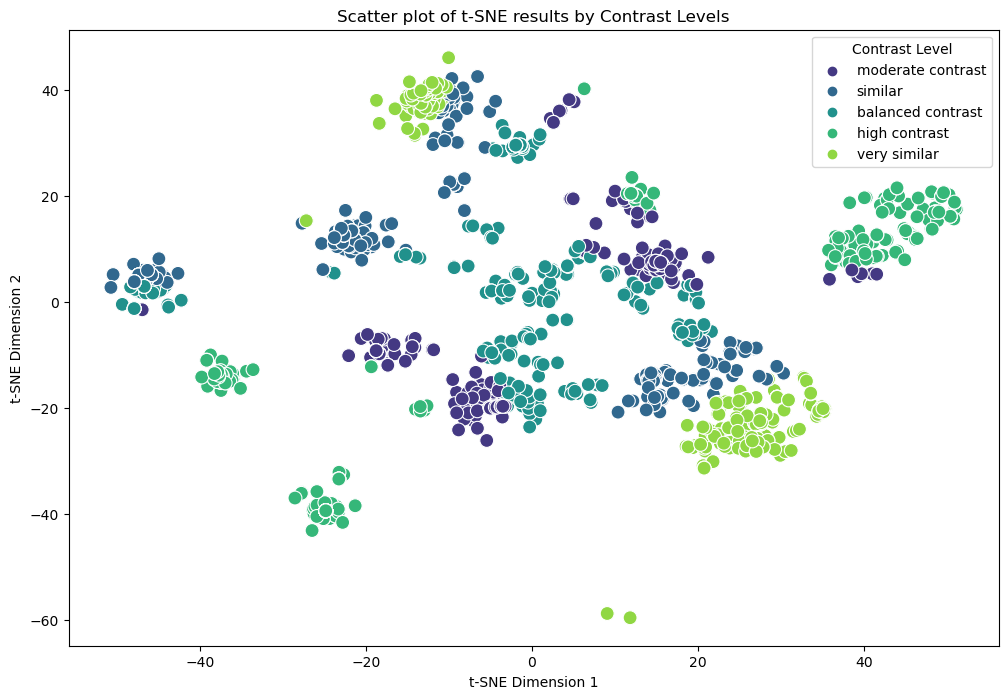

In [23]:

# Step 7: Plot the data based on contrast levels
plt.figure(figsize=(12, 8))
sns.scatterplot(data=data, x='x', y='y', hue='contrast_level', palette='viridis', s=100)
plt.title('Scatter plot of t-SNE results by Contrast Levels')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(title='Contrast Level')
plt.show()

In [24]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_distances
from sklearn.preprocessing import StandardScaler

# Load the CSV file
file_path = 'results.csv'  # Update with the correct file path
data = pd.read_csv(file_path)

# Display the first few rows to understand the structure
print(data.head())

# Assuming the font vectors are in columns, replace 'vector_1', 'vector_2', etc. with actual column names
font_vectors = data.iloc[:, 1:]  # Adjust slicing based on your CSV structure

scaler = StandardScaler()
font_vectors_scaled = scaler.fit_transform(font_vectors)

# Calculate cosine distance matrix
cosine_distance_matrix = cosine_distances(font_vectors)

# Generate font pairs and their distances
font_pairs = []
font_names = data.iloc[:, 0]  # Assuming the first column contains font names

for i in range(len(font_names)):
    for j in range(i + 1, len(font_names)):
        font_pairs.append((font_names[i], font_names[j], cosine_distance_matrix[i, j]))

# Convert to DataFrame for easier viewing
font_pairs_df = pd.DataFrame(font_pairs, columns=['Font1', 'Font2', 'Cosine Distance'])

# Save to CSV if needed
font_pairs_df.to_csv('font_pairs_cosine_distances.csv', index=False)

print(font_pairs_df)


          family  variants_thin  variants_thinitalic  variants_extralight  \
0        ABeeZee              0                    0                    0   
1  ADLaM Display              0                    0                    0   
2    AR One Sans              0                    0                    0   
3           Abel              0                    0                    0   
4   Abhaya Libre              0                    0                    0   

   variants_extralightitalic  variants_light  variants_lightitalic  \
0                          0               0                     0   
1                          0               0                     0   
2                          0               0                     0   
3                          0               0                     0   
4                          0               0                     0   

   variants_medium  variants_mediumitalic  variants_semibold  ...  subsets_yi  \
0                0                 

In [25]:
# Define thresholds for contrast levels
high_contrast_threshold = 0.8
moderate_contrast_threshold = 0.6
balanced_contrast_threshold = 0.4
similar_threshold = 0.2


# Classify font pairs based on cosine distance
def classify_contrast(distance):
    if distance >= high_contrast_threshold:
        return 'High Contrast'
    elif distance >= moderate_contrast_threshold:
        return 'Moderate Contrast'
    elif distance >= balanced_contrast_threshold:
        return 'Balanced Contrast'
    elif distance >= similar_threshold:
        return 'Similar'
    else:
        return 'Very Similar'

font_pairs_df['Contrast Level'] = font_pairs_df['Cosine Distance'].apply(classify_contrast)

# Save to CSV if needed
font_pairs_df.to_csv('font_pairs_contrast_levels.csv', index=False)

print(font_pairs_df)

                 Font1                 Font2  Cosine Distance  \
0              ABeeZee         ADLaM Display         1.767609   
1              ABeeZee           AR One Sans         0.730028   
2              ABeeZee                  Abel         0.177713   
3              ABeeZee          Abhaya Libre         1.222942   
4              ABeeZee               Aboreto         1.718883   
...                ...                   ...              ...   
1427200         Zeyada            Zilla Slab         1.703734   
1427201         Zeyada  Zilla Slab Highlight         1.688157   
1427202  Zhi Mang Xing            Zilla Slab         1.695468   
1427203  Zhi Mang Xing  Zilla Slab Highlight         1.680088   
1427204     Zilla Slab  Zilla Slab Highlight         0.009038   

            Contrast Level  
0            High Contrast  
1        Moderate Contrast  
2             Very Similar  
3            High Contrast  
4            High Contrast  
...                    ...  
1427200      Hig

In [26]:


# Load the CSV file
df = pd.read_csv('font_pairs_contrast_levels.csv')

# Shuffle the DataFrame
df_shuffled = df.sample(frac=1).reset_index(drop=True)

# Save the shuffled DataFrame to a new CSV file
df_shuffled.to_csv('shuffled_pairs.csv', index=False)
